In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/deardiarysampledate/tokenized_data.csv


In [2]:
df=pd.read_csv("/kaggle/input/deardiarysampledate/tokenized_data.csv")
print(df.head())

  label                                               text
0  ADHD  ['called', 'pharmacy', 'confirm', 'could', 'fi...
1  ADHD  ['getting', 'touching', 'grass', 'would', 'giv...
2  ADHD  ['telling', 'friend', 'want', 'feel', 'somethi...
3  ADHD  ['suspected', 'adhd', 'couple', 'month', 'ago'...
4  ADHD  ['inevitable', 'happened', 'feel', 'much', 'li...


BIPOLAR_DISORDER


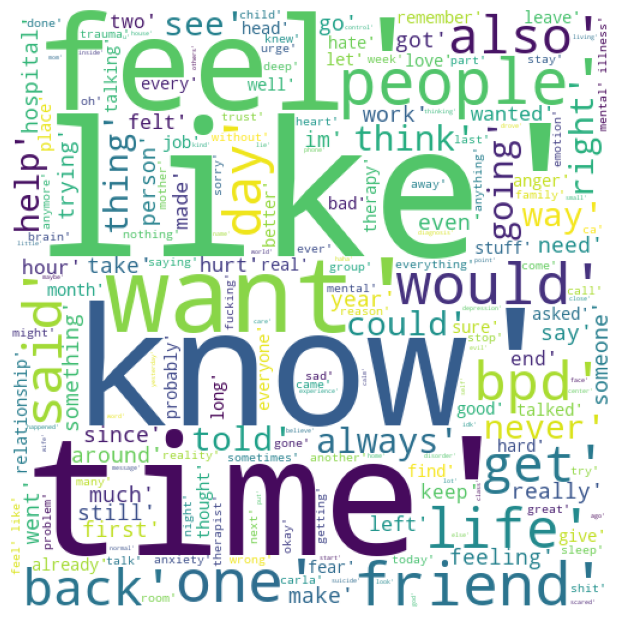


DEPRESSION


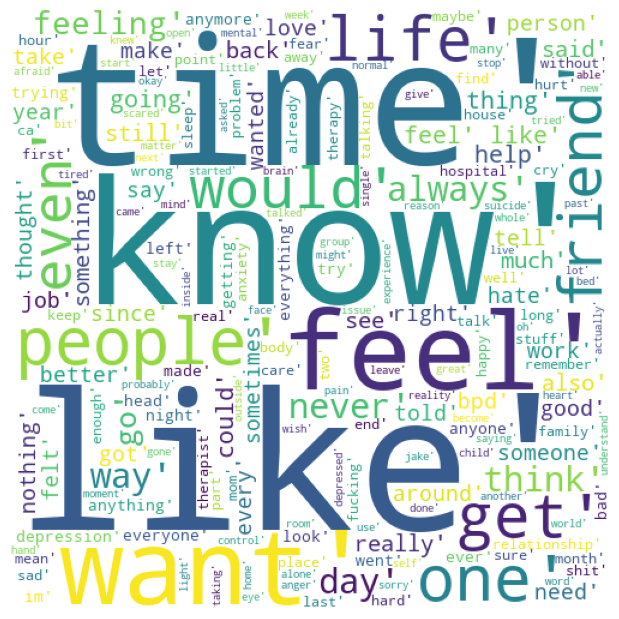


SCHIZOPHRENIA


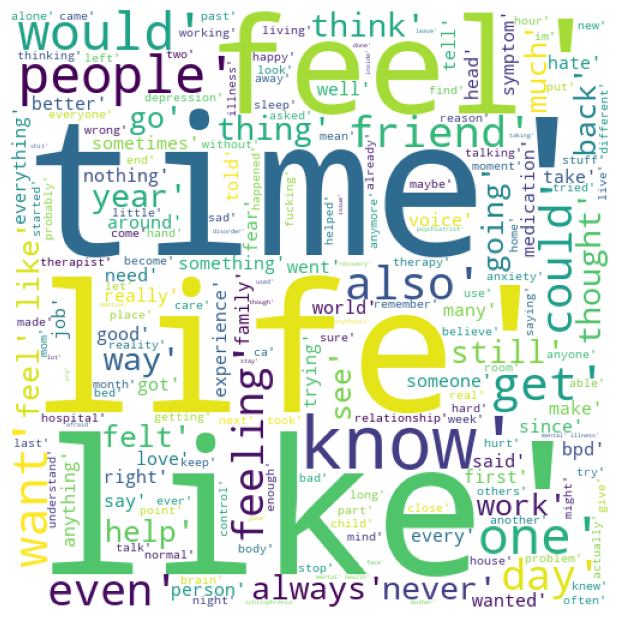


AUTISM


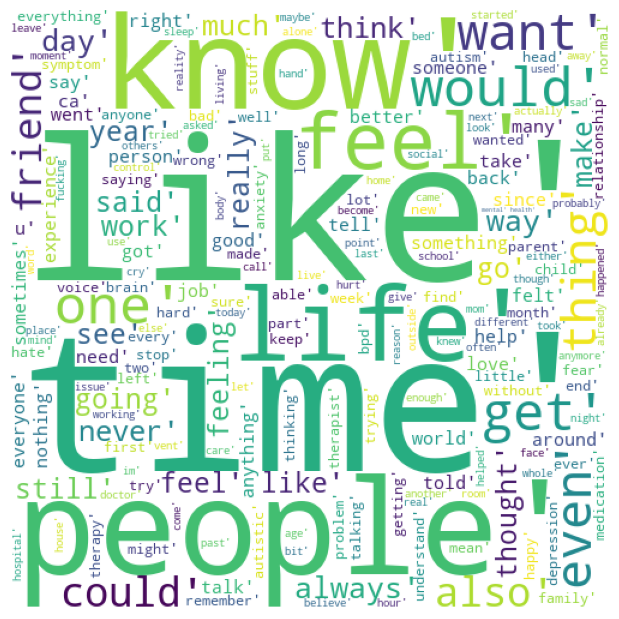


ADHD


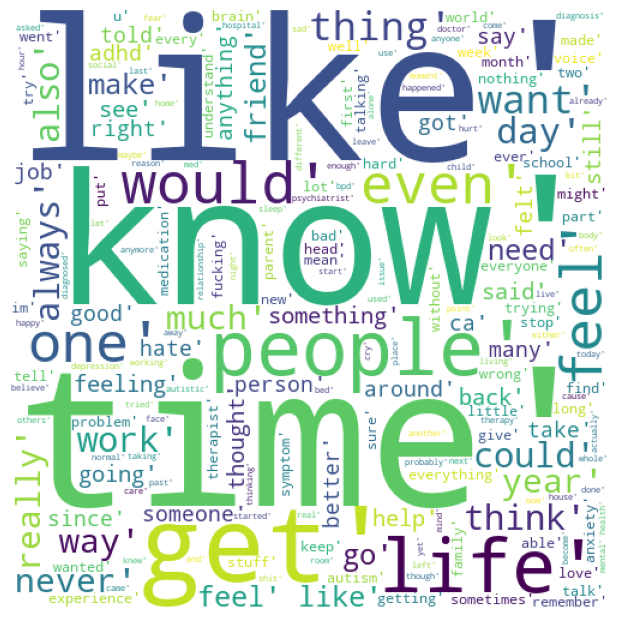


PTSD


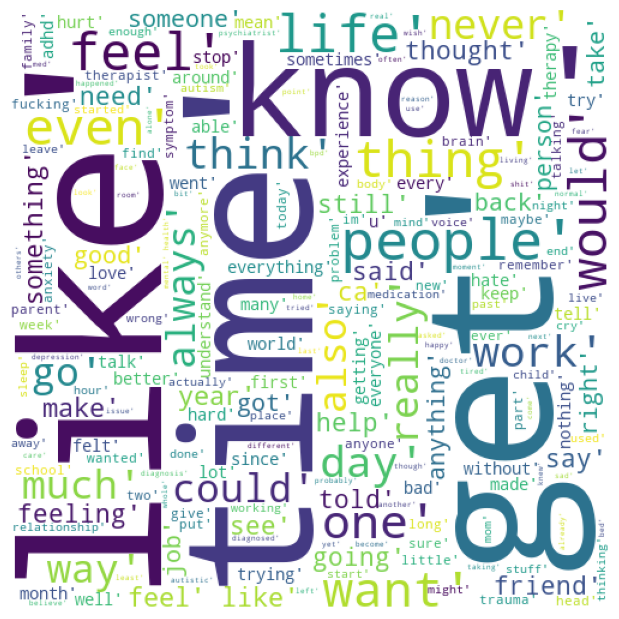


AAM_AADMI


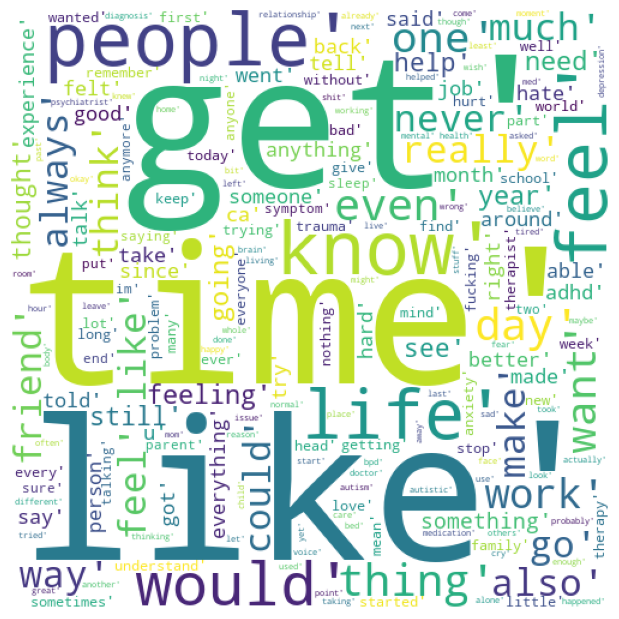


ANXIETY


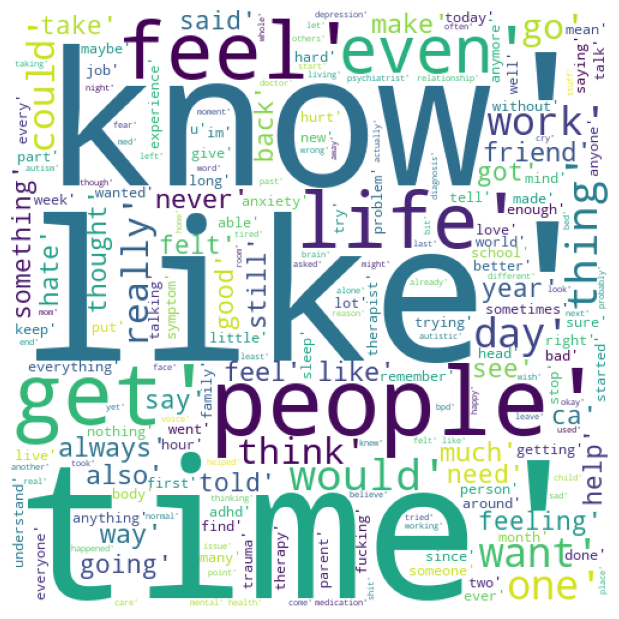

In [3]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
comment_words = ''
stopwords = set(STOPWORDS)
 
l=set([i for i in df.label])

for j in l:
    # iterate through the csv file
    for val in range(len(df.label)):
        if df.iloc[val][0]==j:
            val=df.iloc[val][1]

        # typecaste each val to string
            val = str(val)

            # split the value
            tokens = val.split()

            # Converts each token into lowercase
            for i in range(len(tokens)):
                tokens[i] = tokens[i].lower()

            comment_words += " ".join(tokens)+" "

    wordcloud = WordCloud(width = 500, height = 500,
                    background_color ='white',
                    min_font_size = 5).generate(comment_words)

    # plot the WordCloud image            
    print(j.upper())
    plt.figure(figsize = (6, 6), facecolor = None)
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.tight_layout(pad = 0)

    plt.show()
    print()

In [4]:
all_words = []
df99 = df.apply(lambda x: ' '.join(x.astype(str)), axis=1)
#(df99)
for j in df99:
    l=[]
    tokens = j.split()
    for k in tokens:
        temp=""
        for c in k:
            if c not in ["[","]","'",","]:
                temp+=c
        l.append(temp)
    all_words.append(l)
print(all_words[:2])

[['ADHD', 'called', 'pharmacy', 'confirm', 'could', 'fill', 'script', 'said', 'yes', 'per', 'policy', 'must', 'wait', 'sunday', 'today', 'get', 'text', 'saying', 'backordered', 'end', 'april', 'said', 'place', 'order', 'every', 'day', 'wo', 'know', 'sure', 'ca', 'release', 'info', 'would', 'cause', 'mass', 'rush', 'whatever', 'ca', 'anything', 'right', 'focus', 'issue', 'point', 'calling', 'around', 'ca', 'process', 'sunday', 'one', 'know', 'inventory', 'like', 'sunday', 'furthermore', 'sure', 'provider', 'even', 'work', 'sunday', 'ca', 'take', 'proactive', 'action', 'reactive', 'option', 'reliable', 'either', 'top', 'feel', 'guilty', 'bugging', 'adhd', 'doctor', 'guess', 'psychiatrist', 'correct', 'term', 'specialist', 'think', 'apt'], ['ADHD', 'getting', 'touching', 'grass', 'would', 'give', 'energy', 'need', 'eat', 'food', 'order', 'energy', 'go', 'anywhere', 'touch', 'grass', 'social', 'anxiety', 'drain', 'energy', 'faster', 'touching', 'grass', 'also', 'need', 'eat', 'want', 'want

In [5]:
from gensim.models import Word2Vec

model = Word2Vec(all_words,min_count=2,workers=3, window =5, sg = 1,vector_size=100,negative=4)
#print(model)
#print(model.wv.similarity("ADHD","aam_aadmi"))
#print(model.wv.most_similar("ADHD"))
#print(model.wv["time"])

In [6]:
vocabulary = list(model.wv.index_to_key)
print(len(vocabulary))

3489


In [7]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn import svm
from sklearn.metrics import accuracy_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, chi2


texts = all_words  # List of input texts
labels = [x for x in df.label]  # List of corresponding labels

# Split the dataset into training and testing sets
train_texts, test_texts, train_labels, test_labels = train_test_split(texts, labels, test_size=0.2, random_state=109)

# Encode the labels
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

train_embeddings = []
test_embeddings = []

for text in train_texts:
    
    words = text
    
    # Get the Word2Vec embeddings for each word
    embeddings = []
    for word in words:
        if word in model.wv:
            embeddings.append(model.wv[word])
    
    # Average the word embeddings to get the text representation
    if embeddings:
        text_embedding = np.mean(embeddings, axis=0)
    else:
        text_embedding = np.zeros(model.vector_size)
    
    train_embeddings.append(text_embedding)

for text in test_texts:
    # Preprocess the text (tokenize, remove stopwords, etc.)
    words = text
    
    # Get the Word2Vec embeddings for each word
    embeddings = []
    for word in words:
        if word in model.wv:
            embeddings.append(model.wv[word])
    
    # Average the word embeddings to get the text representation
    if embeddings:
        text_embedding = np.mean(embeddings, axis=0)
    else:
        text_embedding = np.zeros(model.vector_size)
    
    test_embeddings.append(text_embedding)


# Perform feature selection using chi-squared test


for j in range(len(train_embeddings)):
    train_embeddings[j]=abs(train_embeddings[j])
for j in range(len(test_embeddings)):
    test_embeddings[j]=abs(test_embeddings[j])
    
k = 95  # Number of features to select
selector = SelectKBest(chi2, k=k)
train_features_selected = selector.fit_transform(train_embeddings, train_labels)
test_features_selected = selector.transform(test_embeddings)



# Train a model
#classifier = LogisticRegression()
#classifier=GaussianNB()
classifier=svm.SVC(C=0.7,kernel="poly",degree=8,gamma="scale",break_ties=False,random_state=True)
classifier.fit(train_features_selected, train_labels_encoded)

# Make predictions on the test set
predictions = classifier.predict(test_features_selected)
predictions_train = classifier.predict(train_features_selected)

# Decode the predicted labels
predicted_labels = label_encoder.inverse_transform(predictions)
predicted_labels_train = label_encoder.inverse_transform(predictions_train)
#print(predictions)

# classification report
accuracy = accuracy_score(train_labels, predicted_labels_train)
print("Training_Accuracy:", accuracy)
print(classification_report(test_labels, predicted_labels))


Training_Accuracy: 0.8608058608058609
                  precision    recall  f1-score   support

            ADHD       0.62      0.62      0.62        13
         Anxiety       1.00      0.62      0.77         8
          Autism       0.64      0.50      0.56        14
Bipolar_disorder       0.36      0.45      0.40        11
      Depression       0.45      0.62      0.53         8
            PTSD       0.44      0.44      0.44         9
   Schizophrenia       0.00      0.00      0.00         2
       aam_aadmi       0.80      1.00      0.89         4

        accuracy                           0.55        69
       macro avg       0.54      0.53      0.53        69
    weighted avg       0.57      0.55      0.55        69



In [8]:
'''
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['label'])
'''

"\nfrom sklearn.preprocessing import LabelEncoder\n\nlabel_encoder = LabelEncoder()\n\ndf['label'] = label_encoder.fit_transform(df['label'])\n"

In [9]:
'''
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TfidfVectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,3), max_features=300, max_df=17, min_df=2, norm='l1')

# Fit and transform the text data
tfidf_matrix = vectorizer.fit_transform(df['text'])

# Convert the tfidf_matrix to a DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Optional: Merge the tfidf_df with the original DataFrame
df_tfidf = pd.concat([df, tfidf_df], axis=1)

print(tfidf_df.head())
'''

"\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Initialize the TfidfVectorizer\nvectorizer = TfidfVectorizer(ngram_range=(1,3), max_features=300, max_df=17, min_df=2, norm='l1')\n\n# Fit and transform the text data\ntfidf_matrix = vectorizer.fit_transform(df['text'])\n\n# Convert the tfidf_matrix to a DataFrame\ntfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out())\n\n# Optional: Merge the tfidf_df with the original DataFrame\ndf_tfidf = pd.concat([df, tfidf_df], axis=1)\n\nprint(tfidf_df.head())\n"

In [10]:
'''
import seaborn as sns
from matplotlib import pyplot as plt
sns.scatterplot(x=df_tfidf.label,y=tfidf_df.iloc[:,0])
plt.show()
'''

'\nimport seaborn as sns\nfrom matplotlib import pyplot as plt\nsns.scatterplot(x=df_tfidf.label,y=tfidf_df.iloc[:,0])\nplt.show()\n'

In [11]:
'''
from sklearn.feature_selection import mutual_info_classif,SelectKBest
# Separate the features and target variable
X = tfidf_df
y = df_tfidf["label"]  # Target variable

# Calculate the information gain for each feature
info_gain = mutual_info_classif(X, y)
selector = SelectKBest(mutual_info_classif, k=68)

X_new = selector.fit_transform(X, y)
# Get the selected feature names
selected_features = X.columns[selector.get_support()]

# Print the selected feature names
l = tfidf_df.columns
l2 = [j for j in l if j not in selected_features]
tfidf_df2 = tfidf_df.drop(l2, axis=1)
print(tfidf_df2.shape)
'''

'\nfrom sklearn.feature_selection import mutual_info_classif,SelectKBest\n# Separate the features and target variable\nX = tfidf_df\ny = df_tfidf["label"]  # Target variable\n\n# Calculate the information gain for each feature\ninfo_gain = mutual_info_classif(X, y)\nselector = SelectKBest(mutual_info_classif, k=68)\n\nX_new = selector.fit_transform(X, y)\n# Get the selected feature names\nselected_features = X.columns[selector.get_support()]\n\n# Print the selected feature names\nl = tfidf_df.columns\nl2 = [j for j in l if j not in selected_features]\ntfidf_df2 = tfidf_df.drop(l2, axis=1)\nprint(tfidf_df2.shape)\n'

In [12]:
'''
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Assuming you have your feature matrix X and target vector y ready
X=tfidf_df2
y=df_tfidf.iloc[:,0]

# Step 1: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=47)

# Step 4: Train the Gaussian Naive Bayes classifier
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Step 5: Make predictions on the testing data
y_pred = gnb.predict(X_test)
y_pred_train=gnb.predict(X_train)
# Step 6: Evaluate the accuracy of the classifier
accuracy = accuracy_score(y_test, y_pred)
print("test Accuracy: {:.2f}%".format(accuracy * 100))
accuracy = accuracy_score(y_train, y_pred_train)
print("train Accuracy: {:.2f}%".format(accuracy * 100))x
'''

'\nfrom sklearn.decomposition import PCA\nfrom sklearn.naive_bayes import GaussianNB\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import accuracy_score\n\n# Assuming you have your feature matrix X and target vector y ready\nX=tfidf_df2\ny=df_tfidf.iloc[:,0]\n\n# Step 1: Split the data into training and testing sets\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=47)\n\n# Step 4: Train the Gaussian Naive Bayes classifier\ngnb = GaussianNB()\ngnb.fit(X_train, y_train)\n\n# Step 5: Make predictions on the testing data\ny_pred = gnb.predict(X_test)\ny_pred_train=gnb.predict(X_train)\n# Step 6: Evaluate the accuracy of the classifier\naccuracy = accuracy_score(y_test, y_pred)\nprint("test Accuracy: {:.2f}%".format(accuracy * 100))\naccuracy = accuracy_score(y_train, y_pred_train)\nprint("train Accuracy: {:.2f}%".format(accuracy * 100))x\n'